In [61]:
from src.gaussian_mixture import GaussianMixtureMAR
from src.dg import DataGenerator

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, logistic, t

import torch

## Data generating

In [62]:
# global parameters
N = 3000
d = 3

## Gaussian mixture with $k=5$

In [63]:
dist = 'gaussian_mixture'

# true parameters of the gaussian mixture
k = 5
mu0 = torch.rand((k, d)) * 2 - 1 # [-1, 1]
sigma0 = torch.rand((k, d)) * 2 # (0, 2)
pi0 = torch.rand(k) + 0.1
pi0 = pi0 / pi0.sum()

dg = DataGenerator(dist, mu=mu0, sigma=sigma0, pi=pi0)
X, M = dg.generate(N, d)

In [64]:
# functions to numerically find the quantile of a 1D Gaussian mixture
def gmm_cdf(x, mu, sigma, pi):
    z = (x - mu) / sigma
    Phi = 0.5 * (1 + torch.erf(z / torch.sqrt(torch.tensor(2., device=z.device))))
    return (pi * Phi).sum()

def gmm_quantile(p, mu, sigma, pi, tol=1e-6, max_iter=1000):
    """
    Compute x such that P(X <= x) = p for a 1D Gaussian mixture.
    use binary search (bisection) to numerically find x.
    """
    lo = (mu - 10 * sigma).min()
    hi = (mu + 10 * sigma).max()

    for _ in range(max_iter):
        mid = (lo + hi) / 2
        if gmm_cdf(mid, mu, sigma, pi) < p:
            lo = mid
        else:
            hi = mid

        if (hi - lo) < tol:
            break

    return (lo + hi) / 2

def true_quantile(dist, q=0.1, mu=None, sigma=None, pi=None, tol=1e-6, max_iter=100, df=None):
    if dist == 'Normal':
        return norm.ppf(q)
    elif dist == 'gaussian_mixture' and all(x is not None for x in (mu, sigma, pi)):
        return gmm_quantile(q, mu, sigma, pi, tol, max_iter)
    elif dist == 'Logistic':
        return logistic.ppf(q)
    elif dist == 'Student t':
        return t.ppf(q, df)

In [65]:
# GMM settings
cov_type = 'id' # diag, id, uni_diag, uni_id
n_k = 10
start = 0
step = 1
n_mc = 100
n_samples = 3000
k_range = range(2, 9)

gmm = GaussianMixtureMAR(
    k_range=k_range,
    criterion='bic',
    device='cpu',
    cov_type=cov_type,
    n_init=20
    )
gmm.fit(X, M)

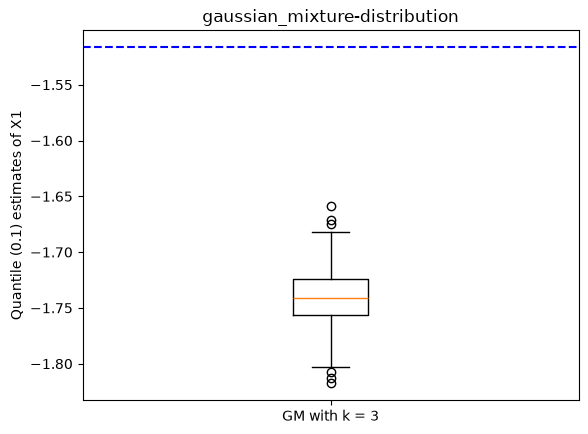

In [66]:
q_x1 = [np.quantile(gmm.sample(n_samples)[0], 0.1) for _ in range(500)]

q = true_quantile(dist=dist, q=0.1, mu=mu0[:,0], sigma=sigma0[:,0], pi=pi0)

plt.boxplot(q_x1, tick_labels=[f'GM with k = {gmm.best_k}'])
plt.axhline(y=q, color='blue', linestyle='--')
plt.ylabel("Quantile (0.1) estimates of X1")
plt.title(f'{dist}-distribution')
plt.show()

## Normal with 
$$\Sigma = \begin{bmatrix} 1 & 0.7 & 0 \\ 0.7 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

In [67]:
# param_vals
dist = 'Normal' # Logistic, Normal, Student t
alpha = 0.7

#df = 3 # for Student t in particular
dg = DataGenerator(dist, alpha, delta=0.01)
X, M = dg.generate(N, d)

In [68]:
# GMM settings
cov_type = 'id' # diag, id, uni_diag, uni_id
n_k = 10
start = 0
step = 1
n_mc = 100
n_samples = 3000

In [69]:
k_range = range(2, 9)

gmm = GaussianMixtureMAR(
    k_range=k_range,
    criterion='bic',
    device='cpu',
    cov_type=cov_type,
    n_init=20
    )
gmm.fit(X, M)

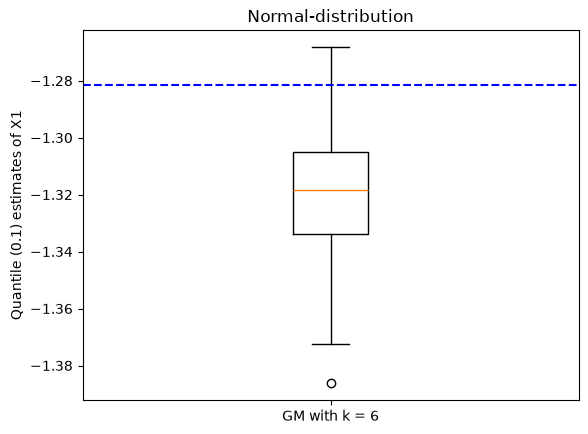

In [70]:
q_x1 = [np.quantile(gmm.sample(n_samples)[0], 0.1) for _ in range(500)]

q = true_quantile(dist)

plt.boxplot(q_x1, tick_labels=[f'GM with k = {gmm.best_k}'])
plt.axhline(y=q, color='blue', linestyle='--')
plt.ylabel("Quantile (0.1) estimates of X1")
plt.title(f'{dist}-distribution')
plt.show()

In [71]:
from src.metrics import energy_distance

In [72]:
energy_distance(X, gmm.sample(n_samples)[0])

tensor(0.0016, dtype=torch.float64)